In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

distill_df = pd.read_json(
    "../../out/distillation/gsm8k_distilled_cot.jsonl",
    lines=True,
)

distill_df

,question,answer,reasoning,distill_ans_correct,distill_response,distill_answer
0,Natalia sold clips to 48 of her friends in Apr...,72,Natalia sold 48/2 = <<48/2=24>>24 clips in May...,True,"To solve this problem, I will first identify t...",72
1,Weng earns $12 an hour for babysitting. Yester...,10,Weng earns 12/60 = $<<12/60=0.2>>0.2 per minut...,True,"To solve this problem, we need to first unders...",10
2,Betty is saving money for a new wallet which c...,5,"In the beginning, Betty has only 100 / 2 = $<<...",True,"To find out how much more money Betty needs, w...",5
3,"Julie is reading a 120-page book. Yesterday, s...",42,Maila read 12 x 2 = <<12*2=24>>24 pages today....,True,"To solve this problem, let's break it down ste...",42
4,James writes a 3-page letter to 2 different fr...,624,He writes each friend 3*2=<<3*2=6>>6 pages a w...,True,"To solve this problem, let's break it down int...",624
...,...,...,...,...,...,...
7468,"Very early this morning, Elise left home in a ...",5,"For the distance she traveled, Elise paid 23 -...",True,"To solve this problem, let's break it down int...",5
7469,Josh is saving up for a box of cookies. To rai...,3,He makes $.5 profit on each bracelet because 1...,True,"To solve this problem, let's break it down ste...",3
7470,Colin can skip at six times the speed that Bra...,4,Tony can skip at twice the speed that Bruce ca...,True,"## Step 1\nFirst, let's understand the problem...",4
7471,"Janet, a third grade teacher, is picking up th...",308,Janet needs 35 lunches for the kids + 5 for th...,True,"To find the total cost of the sack lunches, we...",308


In [2]:
entropy_df = pd.read_json(
    "../../out/single_token_entropy/gsm8k_llama_3b.jsonl",
    lines=True,
)

entropy_df

,question,answer,reasoning,reasoning_w_tools,entropy_ans_correct,entropy_value,entropy_ans
0,Natalia sold clips to 48 of her friends in Apr...,72,Natalia sold 48/2 = 24 clips in May.\nNatalia ...,Natalia sold 48/2 = <<48/2=24>>24 clips in May...,False,0.014363,48 + (48 / 2) =
1,Weng earns $12 an hour for babysitting. Yester...,10,Weng earns 12/60 = $0.2 per minute.\nWorking 5...,Weng earns 12/60 = $<<12/60=0.2>>0.2 per minut...,False,0.029409,6
2,Betty is saving money for a new wallet which c...,5,"In the beginning, Betty has only 100 / 2 = $50...","In the beginning, Betty has only 100 / 2 = $<<...",False,0.133693,100 - 50 + 15 + 30
3,"Julie is reading a 120-page book. Yesterday, s...",42,Maila read 12 x 2 = 24 pages today.\nSo she wa...,Maila read 12 x 2 = <<12*2=24>>24 pages today....,False,0.003955,120 - 12 - 24 = 84
4,James writes a 3-page letter to 2 different fr...,624,He writes each friend 3*2=6 pages a week\nSo h...,He writes each friend 3*2=<<3*2=6>>6 pages a w...,False,0.030595,3 * 2 * 52 = 312
...,...,...,...,...,...,...,...
7468,"Very early this morning, Elise left home in a ...",5,"For the distance she traveled, Elise paid 23 -...","For the distance she traveled, Elise paid 23 -...",False,0.016239,19
7469,Josh is saving up for a box of cookies. To rai...,3,He makes $.5 profit on each bracelet because 1...,He makes $.5 profit on each bracelet because 1...,False,0.229639,12 * 1.5 - 12 *
7470,Colin can skip at six times the speed that Bra...,4,Tony can skip at twice the speed that Bruce ca...,Tony can skip at twice the speed that Bruce ca...,False,0.746229,2
7471,"Janet, a third grade teacher, is picking up th...",308,Janet needs 35 lunches for the kids + 5 for th...,Janet needs 35 lunches for the kids + 5 for th...,False,0.012019,35 + 5 + 1 + 3


In [4]:
distill_df = distill_df[['question', 'distill_response']]

In [5]:
df = distill_df.merge(entropy_df, on='question', suffixes=('_distill', '_entropy'), how='inner')

In [6]:
df.describe()

,entropy_value
count,7473.000000
mean,0.420405
std,0.540685
min,0.000014
25%,0.010017
50%,0.109547
75%,0.742320
max,4.360105


In [7]:
df

,question,distill_response,answer,reasoning,reasoning_w_tools,entropy_ans_correct,entropy_value,entropy_ans
0,Natalia sold clips to 48 of her friends in Apr...,"To solve this problem, I will first identify t...",72,Natalia sold 48/2 = 24 clips in May.\nNatalia ...,Natalia sold 48/2 = <<48/2=24>>24 clips in May...,False,0.014363,48 + (48 / 2) =
1,Weng earns $12 an hour for babysitting. Yester...,"To solve this problem, we need to first unders...",10,Weng earns 12/60 = $0.2 per minute.\nWorking 5...,Weng earns 12/60 = $<<12/60=0.2>>0.2 per minut...,False,0.029409,6
2,Betty is saving money for a new wallet which c...,"To find out how much more money Betty needs, w...",5,"In the beginning, Betty has only 100 / 2 = $50...","In the beginning, Betty has only 100 / 2 = $<<...",False,0.133693,100 - 50 + 15 + 30
3,"Julie is reading a 120-page book. Yesterday, s...","To solve this problem, let's break it down ste...",42,Maila read 12 x 2 = 24 pages today.\nSo she wa...,Maila read 12 x 2 = <<12*2=24>>24 pages today....,False,0.003955,120 - 12 - 24 = 84
4,James writes a 3-page letter to 2 different fr...,"To solve this problem, let's break it down int...",624,He writes each friend 3*2=6 pages a week\nSo h...,He writes each friend 3*2=<<3*2=6>>6 pages a w...,False,0.030595,3 * 2 * 52 = 312
...,...,...,...,...,...,...,...,...
7468,"Very early this morning, Elise left home in a ...","To solve this problem, let's break it down int...",5,"For the distance she traveled, Elise paid 23 -...","For the distance she traveled, Elise paid 23 -...",False,0.016239,19
7469,Josh is saving up for a box of cookies. To rai...,"To solve this problem, let's break it down ste...",3,He makes $.5 profit on each bracelet because 1...,He makes $.5 profit on each bracelet because 1...,False,0.229639,12 * 1.5 - 12 *
7470,Colin can skip at six times the speed that Bra...,"## Step 1\nFirst, let's understand the problem...",4,Tony can skip at twice the speed that Bruce ca...,Tony can skip at twice the speed that Bruce ca...,False,0.746229,2
7471,"Janet, a third grade teacher, is picking up th...","To find the total cost of the sack lunches, we...",308,Janet needs 35 lunches for the kids + 5 for th...,Janet needs 35 lunches for the kids + 5 for th...,False,0.012019,35 + 5 + 1 + 3


<Axes: >

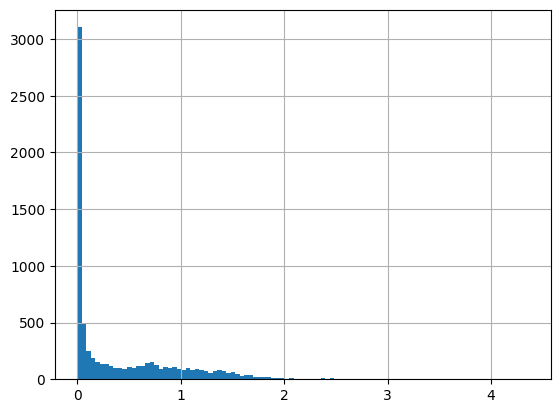

In [8]:
df["entropy_value"].hist(bins=100)

In [9]:
df["norm_entropy"] = df["entropy_value"] / df["entropy_value"].max()

In [10]:
df["norm_entropy"].describe().round(5)

count    7473.00000
mean        0.09642
std         0.12401
min         0.00000
25%         0.00230
50%         0.02512
75%         0.17025
max         1.00000
Name: norm_entropy, dtype: float64

In [11]:
len(df[(df["norm_entropy"] >= 0.17025)])

1869

In [12]:
easy_df = df[(df["norm_entropy"] < 0.00230)]
middle_df = df[(df["norm_entropy"] >= 0.00230) & (df["norm_entropy"] < 0.17025)]
hard_df = df[(df["norm_entropy"] >= 0.17025)]

In [13]:
train_combined_df = pd.concat([easy_df, middle_df, hard_df], ignore_index=True)
train_combined_df

,question,distill_response,answer,reasoning,reasoning_w_tools,entropy_ans_correct,entropy_value,entropy_ans,norm_entropy
0,"Julie is reading a 120-page book. Yesterday, s...","To solve this problem, let's break it down ste...",42,Maila read 12 x 2 = 24 pages today.\nSo she wa...,Maila read 12 x 2 = <<12*2=24>>24 pages today....,False,0.003955,120 - 12 - 24 = 84,0.000907
1,Albert is wondering how much pizza he can eat ...,"To solve this problem, let's first identify th...",48,He eats 32 from the largest pizzas because 2 x...,He eats 32 from the largest pizzas because 2 x...,False,0.006481,2 x 16 = 32\n2 x,0.001487
2,Alexis is applying for a new job and bought a ...,To find out how much Alexis paid for the shoes...,41,Let S be the amount Alexis paid for the shoes....,Let S be the amount Alexis paid for the shoes....,False,0.001378,200 - 30 - 46 - 38,0.000316
3,Randy has 60 mango trees on his farm. He also ...,"To solve this problem, we will break it down s...",85,Half of the number of Randy's mango trees is 6...,Half of the number of Randy's mango trees is 6...,False,0.003604,60 + (60 / 2 - 5,0.000827
4,It takes Roque two hours to walk to work and o...,"To solve this problem, we need to break it dow...",16,Roque takes 2*3 = 6 hours a week to walk to wo...,Roque takes 2*3 = <<2*3=6>>6 hours a week to w...,False,0.008873,2 * 3 + 1 * 2,0.002035
...,...,...,...,...,...,...,...,...,...
7468,"Mr. Rainwater has some goats, 9 cows and some ...","To solve this problem, let's break it down int...",18,Let X be the number of chickens Mr. Rainwater ...,Let X be the number of chickens Mr. Rainwater ...,False,1.086157,Let's break it down:\n\nLet's say the,0.249113
7469,A factory decides to stop making cars and star...,"To solve this problem, I will break it down in...",50,They sold $200 worth of cars each month becaus...,They sold $200 worth of cars each month becaus...,False,1.484438,"To find the profit from making cars, we need",0.340459
7470,Polly and Gerald went for a fun afternoon ridi...,## Step 1: Determine the distance Polly travel...,3,Polly circled the one-quarter mile track 12 ti...,Polly circled the one-quarter mile track 12 ti...,False,1.583885,"To find Gerald's speed, we need to first",0.363268
7471,Colin can skip at six times the speed that Bra...,"## Step 1\nFirst, let's understand the problem...",4,Tony can skip at twice the speed that Bruce ca...,Tony can skip at twice the speed that Bruce ca...,False,0.746229,2,0.171149


In [14]:
train_random_df = train_combined_df.sample(618, random_state=42)

In [15]:
easy_df.to_json("../entropy/llama/gsm8k_train_easy.jsonl", lines=True, orient="records")
middle_df.to_json("../entropy/llama/gsm8k_train_middle.jsonl", lines=True, orient="records")
hard_df.to_json("../entropy/llama/gsm8k_train_hard.jsonl", lines=True, orient="records")
train_combined_df.to_json("../entropy/llama/gsm8k_train_combined.jsonl", lines=True, orient="records")
train_random_df.to_json("../entropy/llama/gsm8k_train_random.jsonl", lines=True, orient="records")